# Letter Recognition Classification

**Dataset:** [UCI Letter Recognition](https://archive.ics.uci.edu/dataset/59/letter+recognition)  
**Goal:** Classify 26 capital English letters using 16 pixel-derived numerical features extracted from raster images.  
**Models:** Random Forest and K-Nearest Neighbours (KNN) with hyperparameter tuning via GridSearchCV.

| | |
|---|---|
| Instances | 20,000 |
| Features | 16 (numerical) |
| Classes | 26 (A–Z) |
| Missing values | None |

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plot
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

letter_recognition = pd.read_csv('letter-recognition.csv', sep=',', decimal='.')
print(f"Dataset shape: {letter_recognition.shape}")
letter_recognition.head(5)

Dataset shape: (20000, 17)


,lettr,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


## 2. Exploratory Data Analysis

### 2.1 Dataset Overview

Each row is a letter sample. The `lettr` column is the target label. The remaining 16 features are integer statistics derived from the pixel grid of each letter image.

In [2]:
letter_recognition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   lettr   20000 non-null  object
 1   x-box   20000 non-null  int64 
 2   y-box   20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   high    20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   x-bar   20000 non-null  int64 
 7   y-bar   20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybr   20000 non-null  int64 
 12  xy2br   20000 non-null  int64 
 13  x-ege   20000 non-null  int64 
 14  xegvy   20000 non-null  int64 
 15  y-ege   20000 non-null  int64 
 16  yegvx   20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [3]:
letter_recognition.describe().T

,count,mean,std,min,25%,50%,75%,max
x-box,20000.0,4.02355,1.913212,0.0,3.0,4.0,5.0,15.0
y-box,20000.0,7.03550,3.304555,0.0,5.0,7.0,9.0,15.0
width,20000.0,5.12185,2.014573,0.0,4.0,5.0,6.0,15.0
high,20000.0,5.37245,2.261390,0.0,4.0,6.0,7.0,15.0
onpix,20000.0,3.50585,2.190458,0.0,2.0,3.0,5.0,15.0
x-bar,20000.0,6.89760,2.026035,0.0,6.0,7.0,8.0,15.0
y-bar,20000.0,7.50045,2.325354,0.0,6.0,7.0,9.0,15.0
x2bar,20000.0,4.62860,2.699968,0.0,3.0,4.0,6.0,15.0
y2bar,20000.0,5.17865,2.380823,0.0,4.0,5.0,7.0,15.0
xybar,20000.0,8.28205,2.488475,0.0,7.0,8.0,10.0,15.0


### 2.2 Data Quality Check

Checking for missing values and duplicate rows before modelling.

In [4]:
print("Missing values per column:")
print(letter_recognition.isnull().sum())
print(f"\nDuplicate rows: {letter_recognition.duplicated().sum()}")

Missing values per column:
lettr    0
x-box    0
y-box    0
width    0
high     0
onpix    0
x-bar    0
y-bar    0
x2bar    0
y2bar    0
xybar    0
x2ybr    0
xy2br    0
x-ege    0
xegvy    0
y-ege    0
yegvx    0
dtype: int64

Duplicate rows: 1332


No missing values. There are 1,332 duplicate rows, but since these are feature-level pixel statistics (not identifiers), they likely represent genuine repeated patterns in the letter images and are kept.

### 2.3 Class Distribution

Checking whether the dataset is balanced across all 26 letters.

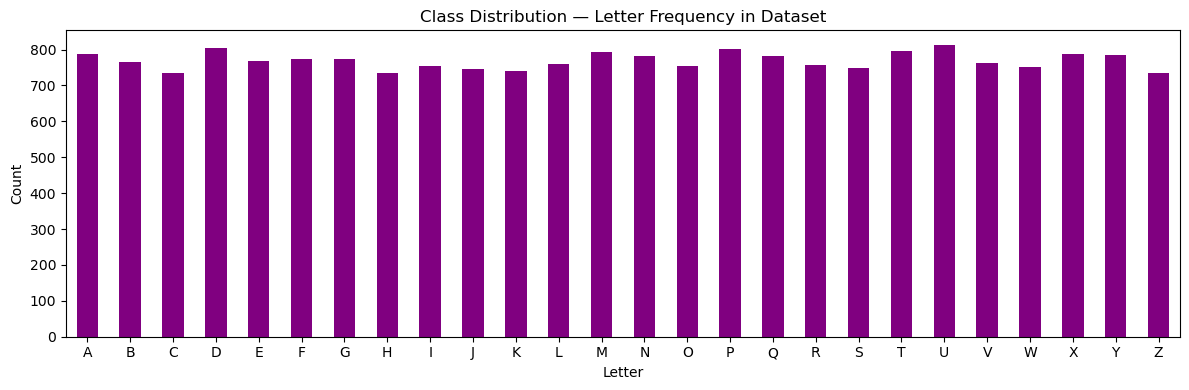

Min: 734 (H)  |  Max: 813 (U)


In [5]:
class_counts = letter_recognition['lettr'].value_counts().sort_index()

class_counts.plot(kind='bar', color='purple', figsize=(12, 4))
plot.title('Class Distribution — Letter Frequency in Dataset')
plot.xlabel('Letter')
plot.ylabel('Count')
plot.xticks(rotation=0)
plot.tight_layout()
plot.show()

print(f"Min: {class_counts.min()} ({class_counts.idxmin()})  |  Max: {class_counts.max()} ({class_counts.idxmax()})")

The dataset is well-balanced — each letter has roughly 750–815 samples, so no class imbalance correction is needed.

## 3. Feature Analysis

The 16 features capture spatial statistics of on-pixels in the letter bounding box:

| Feature | Description |
|---|---|
| x-box, y-box | Horizontal/vertical position of bounding box |
| width, high | Width and height of bounding box |
| onpix | Total number of on pixels |
| x-bar, y-bar | Mean x/y of on pixels |
| x2bar, y2bar | Mean x/y variance |
| xybar | Mean x–y correlation |
| x2ybr, xy2br | Mean of x²y and xy² |
| x-ege, y-ege | Edge counts (left-to-right, bottom-to-top) |
| xegvy, yegvx | Edge–position correlations |

### 3.1 Box Plots by Letter

How each feature varies across the 26 letter classes.

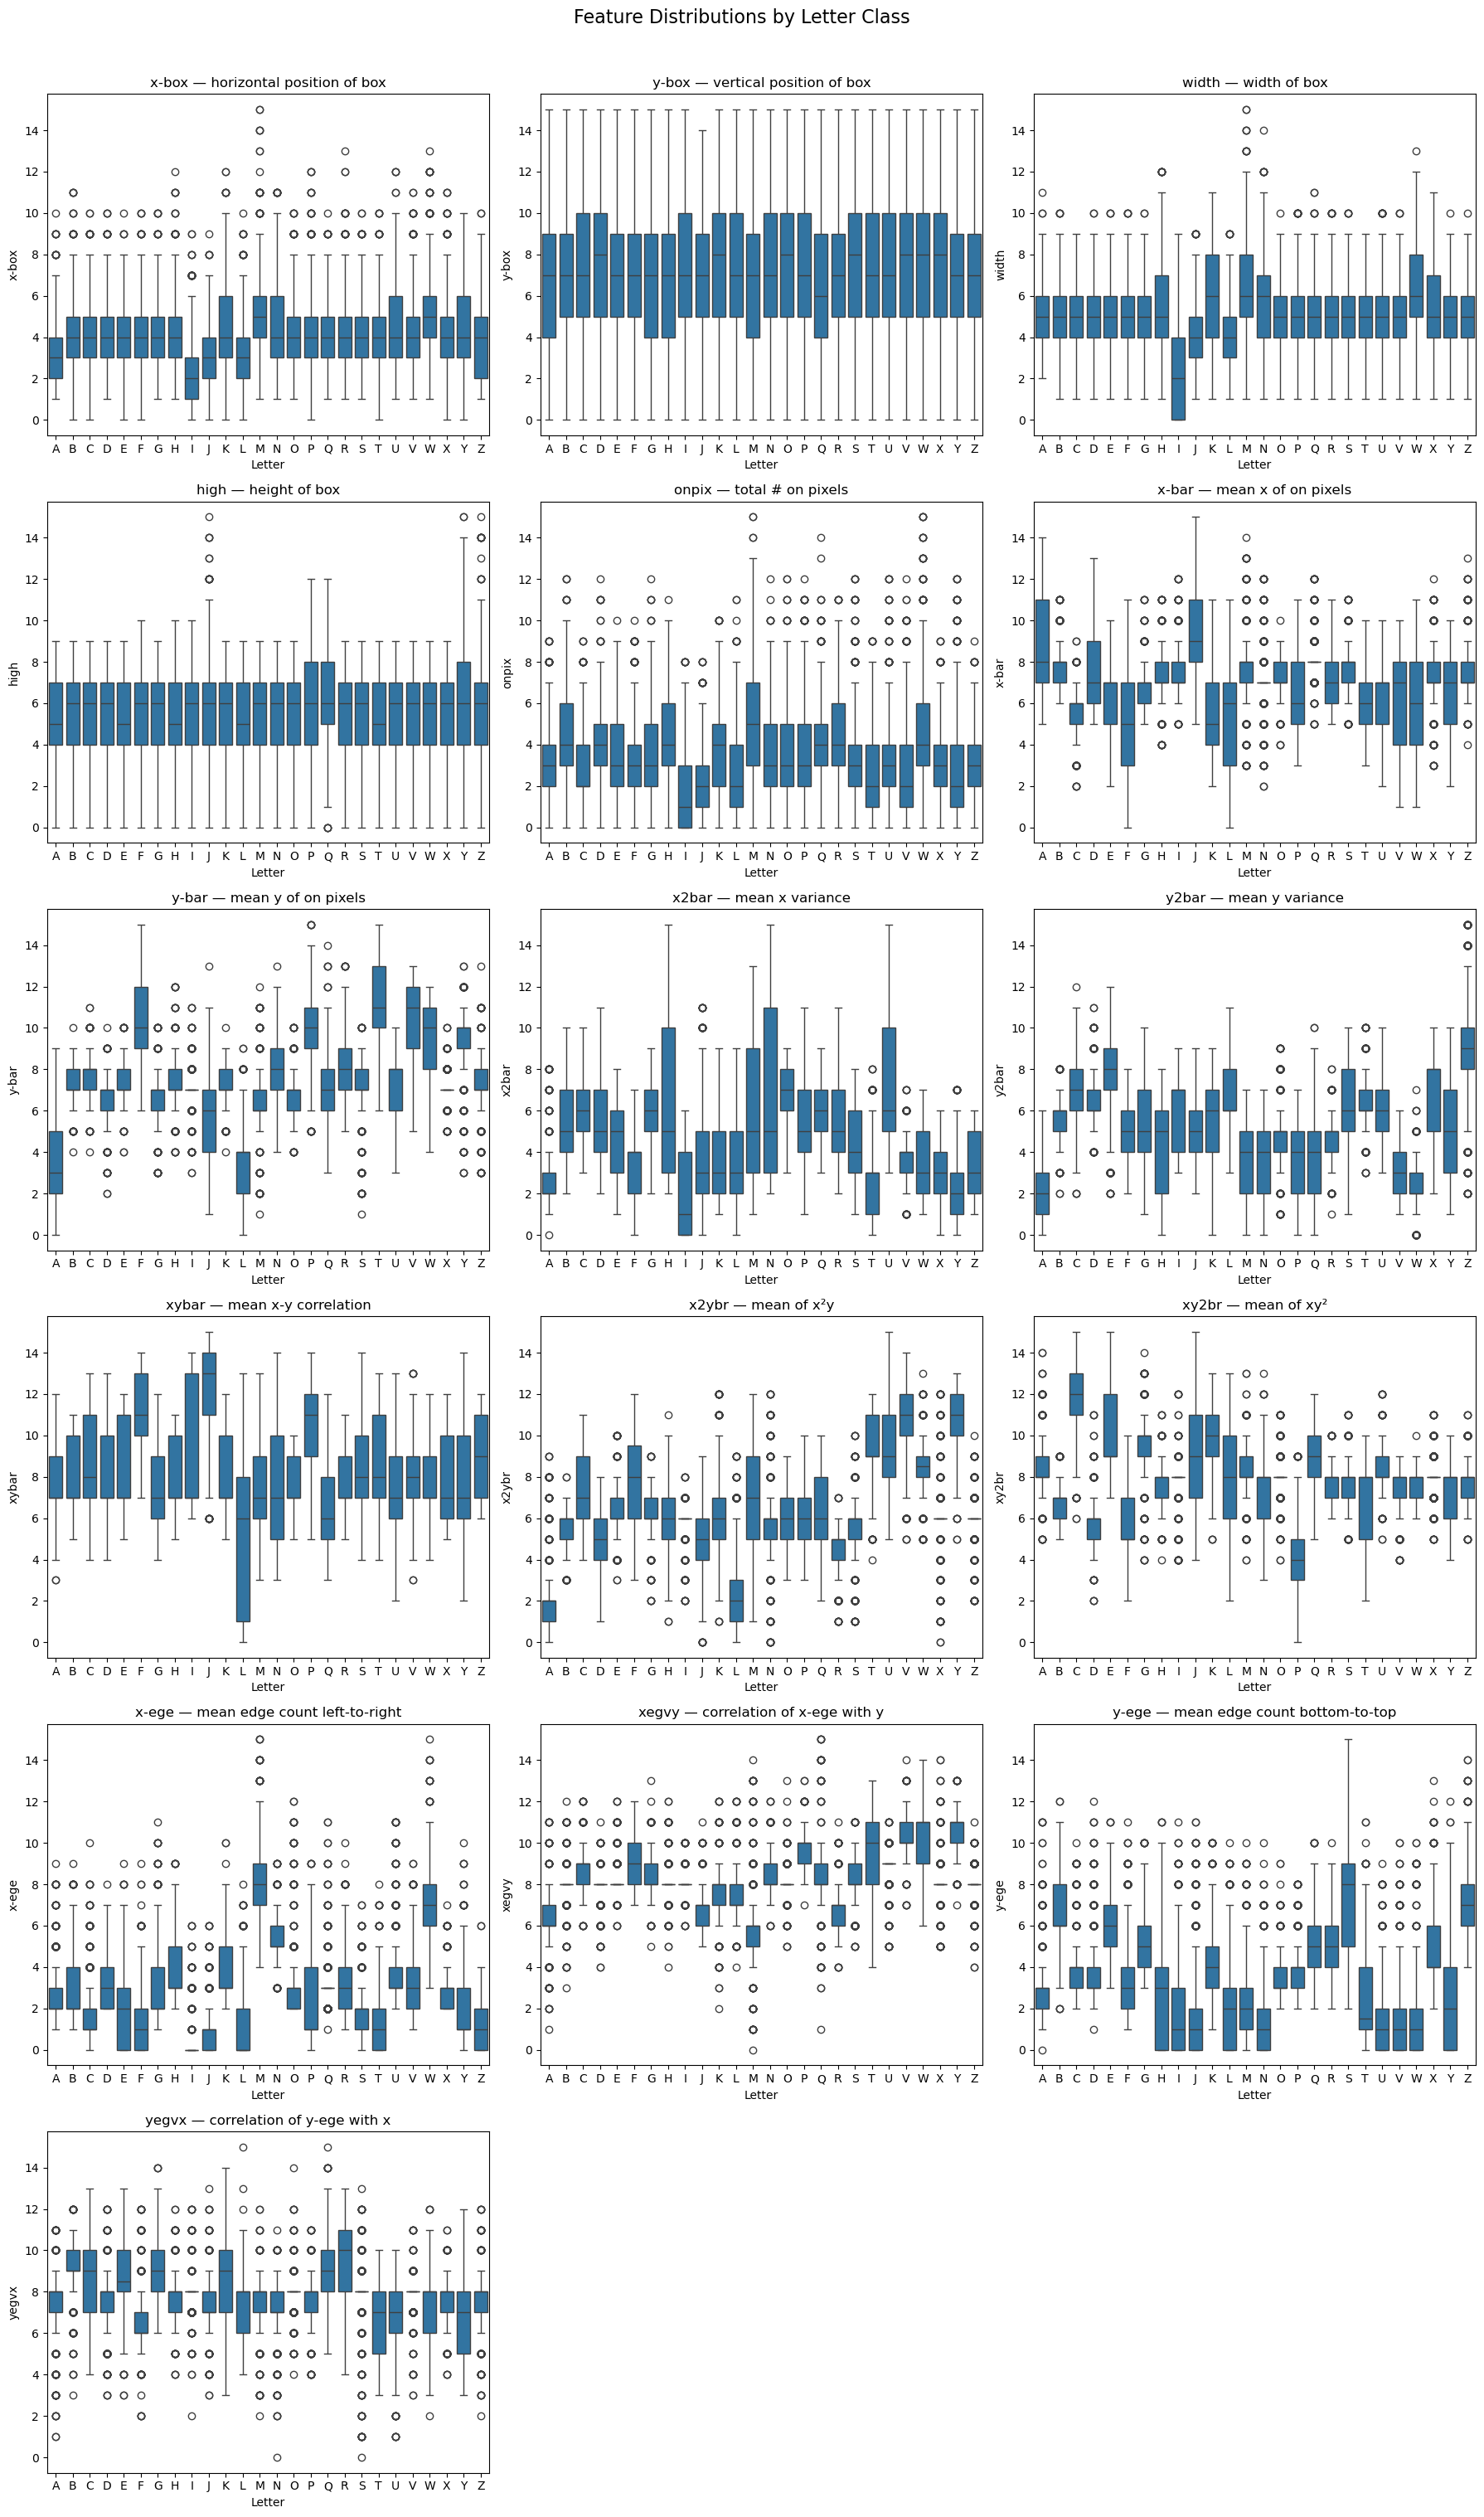

In [6]:
numerical_columns = letter_recognition.columns.drop('lettr')
letters_sorted = sorted(letter_recognition['lettr'].unique())
feature_descriptions = [
    'horizontal position of box', 'vertical position of box',
    'width of box', 'height of box', 'total # on pixels',
    'mean x of on pixels', 'mean y of on pixels',
    'mean x variance', 'mean y variance', 'mean x-y correlation',
    'mean of x²y', 'mean of xy²',
    'mean edge count left-to-right', 'correlation of x-ege with y',
    'mean edge count bottom-to-top', 'correlation of y-ege with x'
]

num_features = len(numerical_columns)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plot.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))
axes = axes.flatten()

for i, (col, desc) in enumerate(zip(numerical_columns, feature_descriptions)):
    sns.boxplot(x='lettr', y=col, data=letter_recognition, order=letters_sorted, ax=axes[i])
    axes[i].set_title(f'{col} — {desc}')
    axes[i].set_xlabel('Letter')
    axes[i].set_ylabel(col)

for j in range(num_features, len(axes)):
    axes[j].axis('off')

plot.suptitle('Feature Distributions by Letter Class', fontsize=16, y=1.01)
plot.tight_layout()
plot.show()

### 3.2 Feature Distributions

Histogram + KDE for each feature to understand skew and spread.

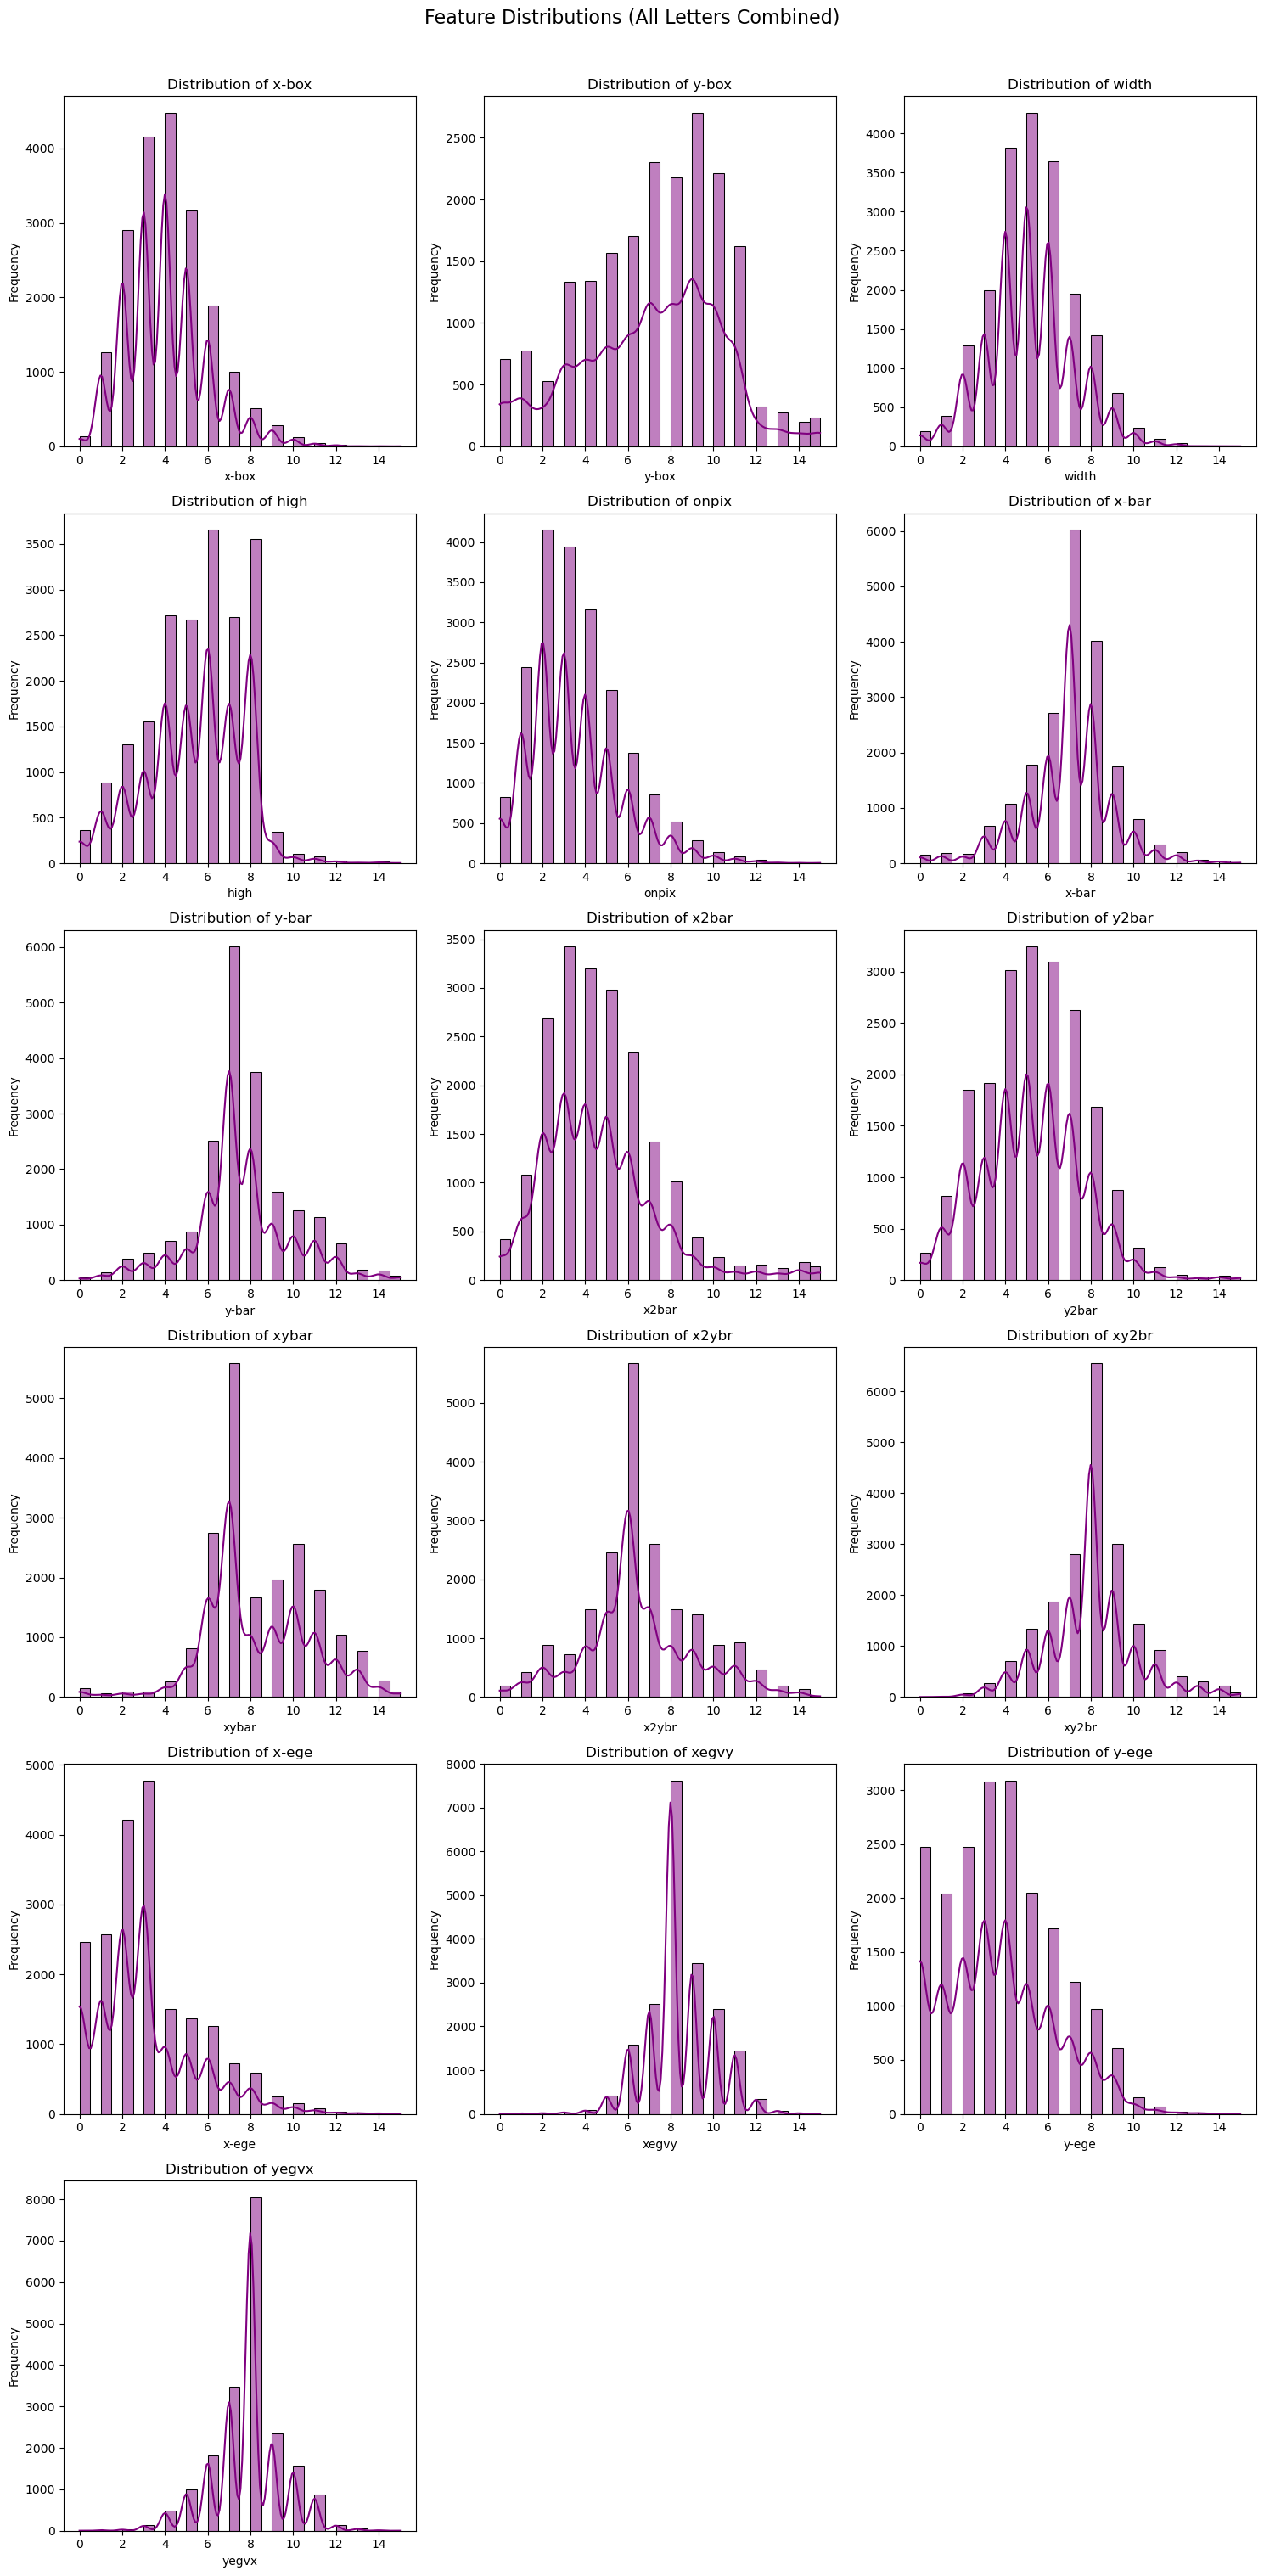

In [7]:
fig, axes = plot.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(letter_recognition[col], kde=True, bins=30, color='purple', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(num_features, len(axes)):
    axes[j].axis('off')

plot.suptitle('Feature Distributions (All Letters Combined)', fontsize=16, y=1.01)
plot.tight_layout()
plot.show()

### 3.3 Pairwise Feature Relationships

Scatter plots for feature pairs with intuitive geometric relationships.

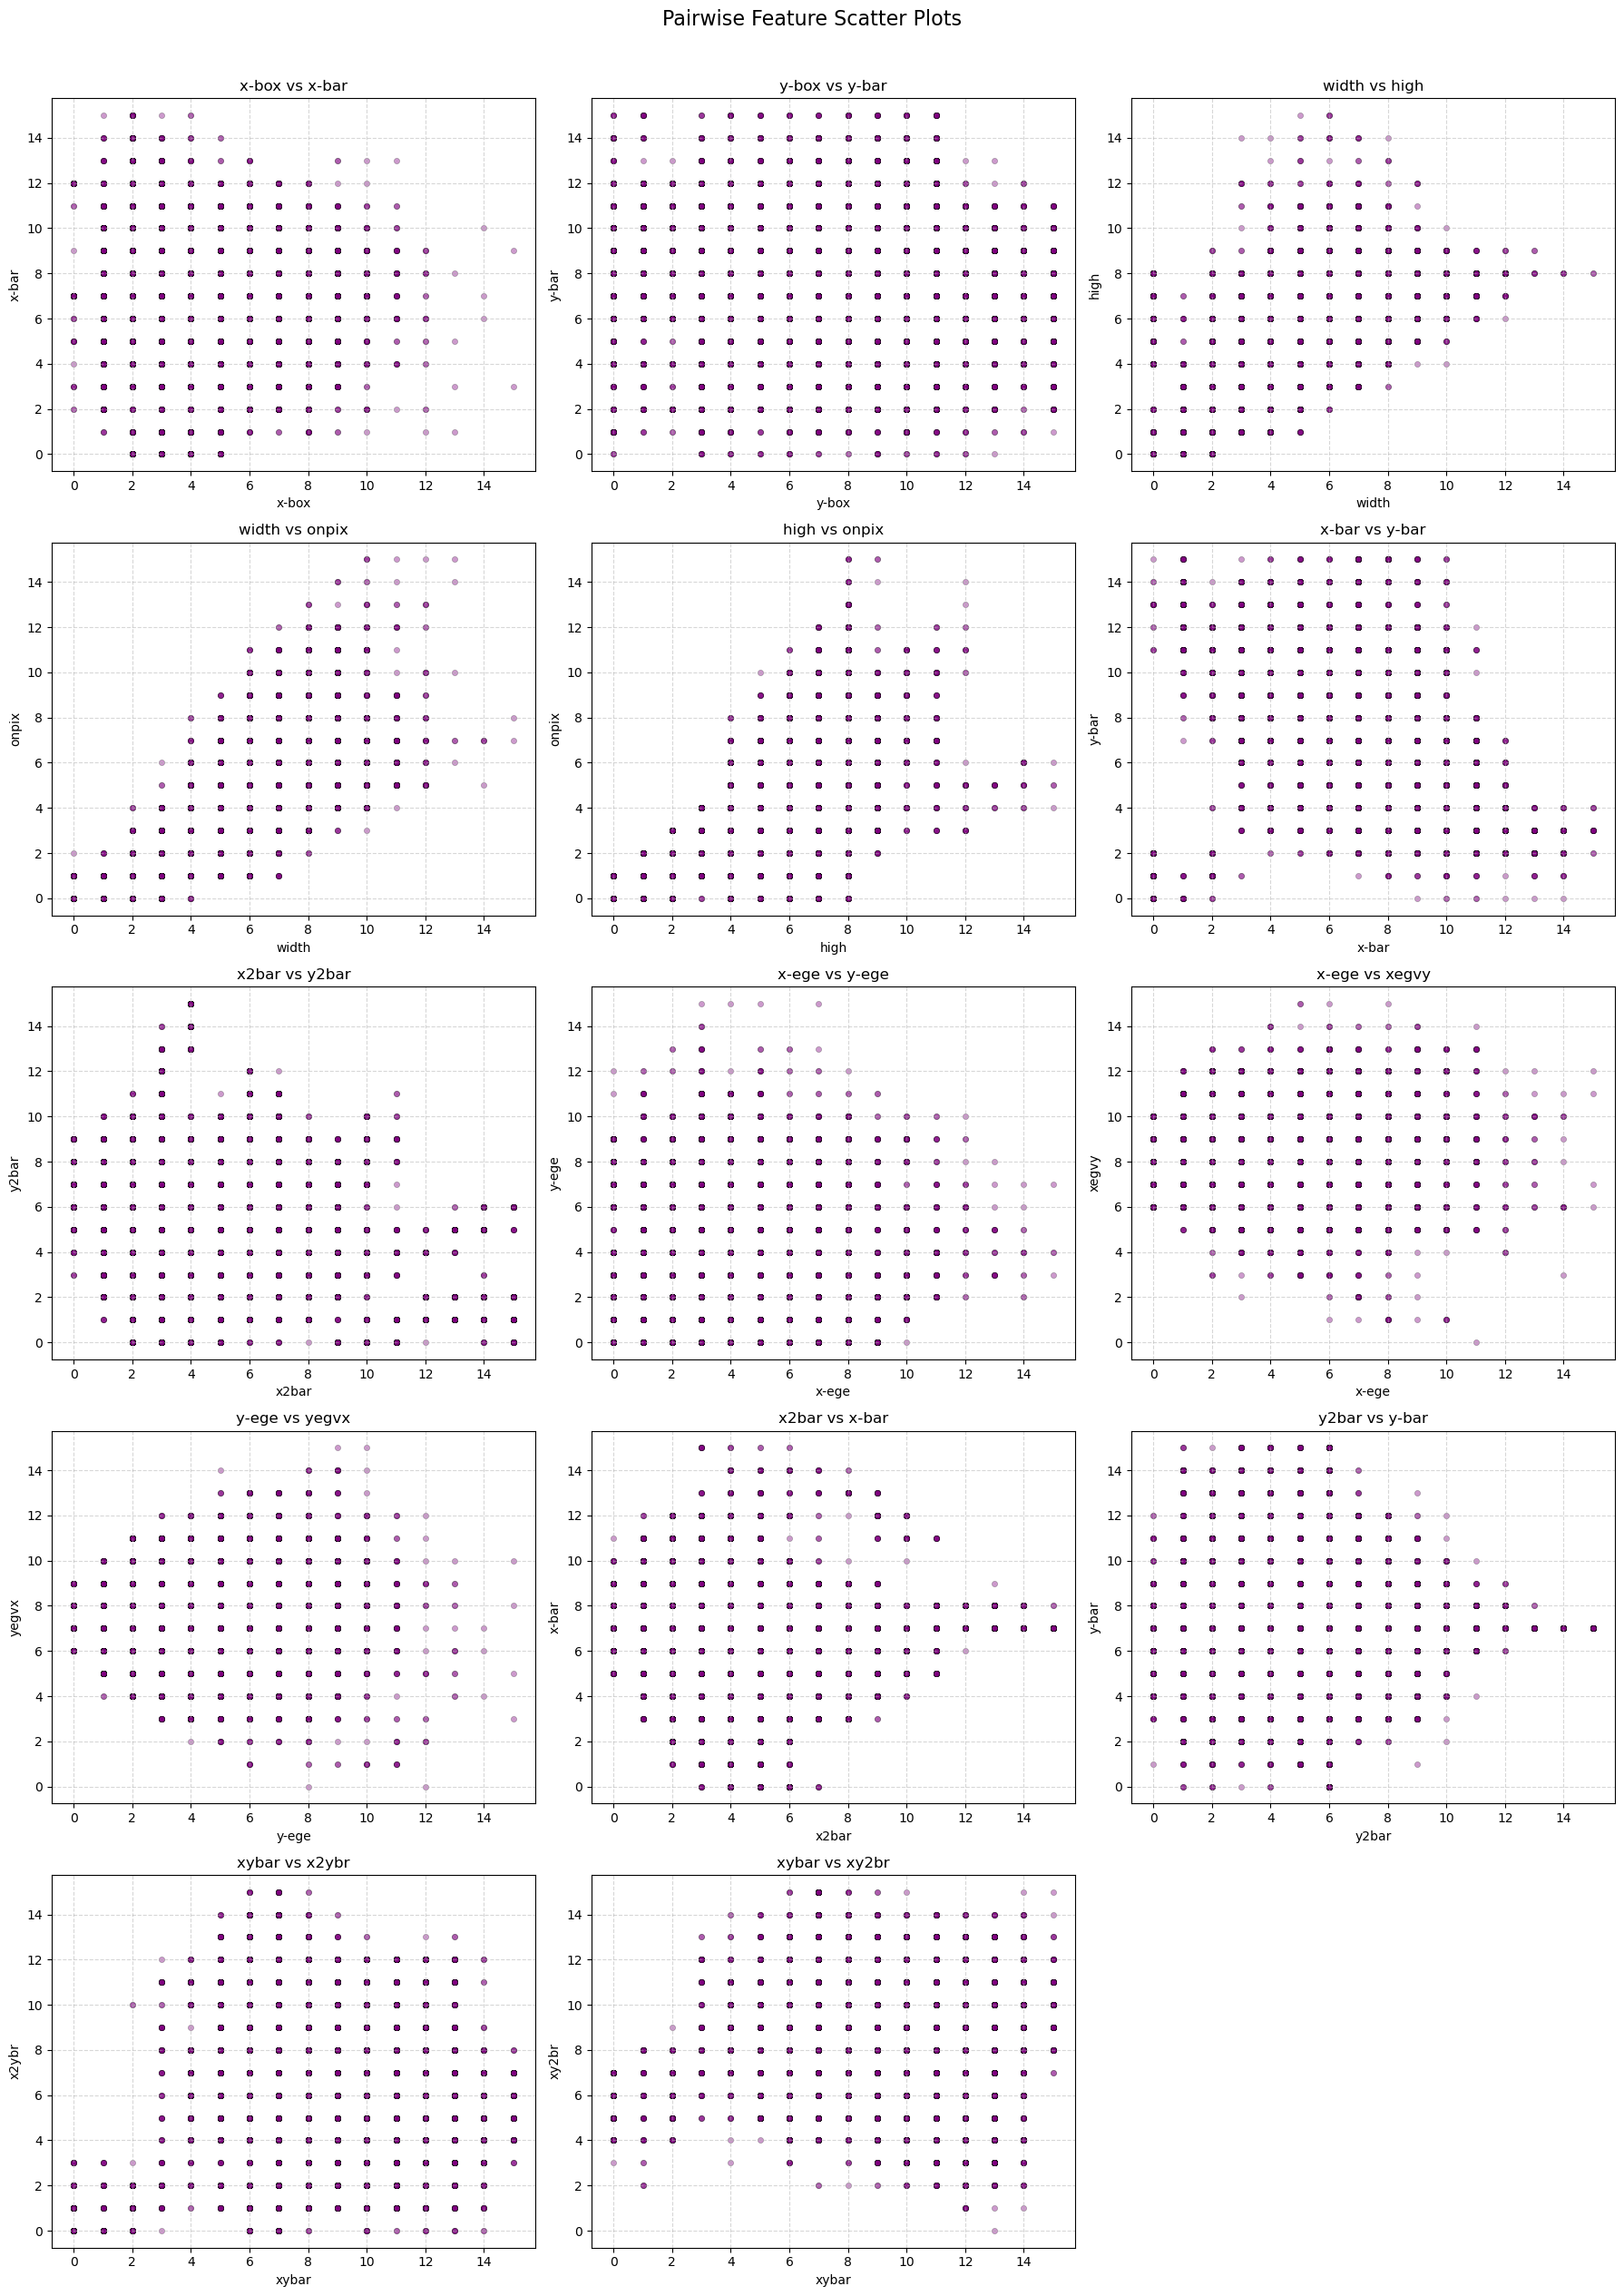

In [8]:
pairs_of_columns = [
    ('x-box', 'x-bar'), ('y-box', 'y-bar'), ('width', 'high'),
    ('width', 'onpix'), ('high', 'onpix'), ('x-bar', 'y-bar'),
    ('x2bar', 'y2bar'), ('x-ege', 'y-ege'), ('x-ege', 'xegvy'),
    ('y-ege', 'yegvx'), ('x2bar', 'x-bar'), ('y2bar', 'y-bar'),
    ('xybar', 'x2ybr'), ('xybar', 'xy2br')
]

num_plots = len(pairs_of_columns)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plot.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))
axes = axes.flatten()

for i, (col1, col2) in enumerate(pairs_of_columns):
    sns.scatterplot(
        x=col1, y=col2, data=letter_recognition,
        alpha=0.4, color='purple', edgecolor='k', s=20, ax=axes[i]
    )
    axes[i].set_title(f'{col1} vs {col2}')
    axes[i].grid(True, linestyle='--', alpha=0.5)

for j in range(num_plots, len(axes)):
    axes[j].axis('off')

plot.suptitle('Pairwise Feature Scatter Plots', fontsize=16, y=1.01)
plot.tight_layout()
plot.show()

### 3.4 Correlation Heatmap

Pearson correlations between all 16 numerical features.

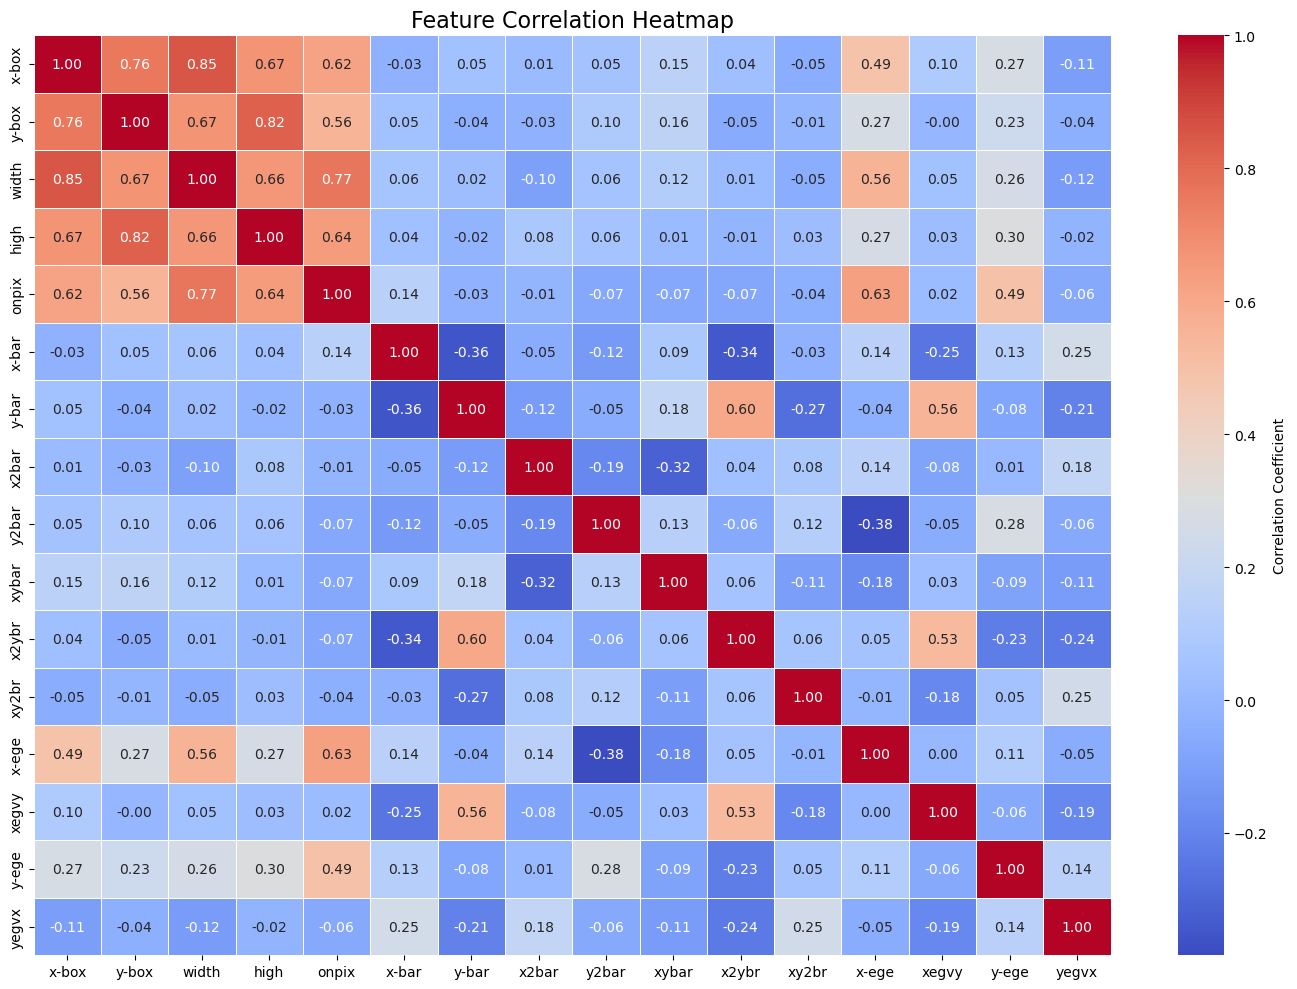

In [9]:
correlation_matrix = letter_recognition.drop('lettr', axis=1).corr()

plot.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'}
)
plot.title('Feature Correlation Heatmap', fontsize=16)
plot.tight_layout()
plot.show()

Most features are weakly correlated, which is expected given they capture different spatial statistics. The highest correlations appear between size-related features (`width`, `high`, `onpix`) — larger letters naturally have more on-pixels.

## 4. Classification Models

Two models are trained and compared:
- **Random Forest** — ensemble of decision trees, robust to noisy features
- **K-Nearest Neighbours (KNN)** — distance-based baseline

Both use 5-fold cross-validated `GridSearchCV` for hyperparameter tuning, an 80/20 train/test split, and stratified sampling to preserve class proportions.

### 4.1 Train/Test Split

In [10]:
X = letter_recognition.drop('lettr', axis=1)
y = letter_recognition['lettr']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 16000 samples
Test set:     4000 samples


### 4.2 Random Forest

Grid search over number of trees, max depth, min samples to split, and number of features per split.

In [11]:
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
rf_best = rf_grid.best_estimator_

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 150}


In [12]:
y_pred_rf = rf_best.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

Random Forest Test Accuracy: 0.9680 (96.80%)


In [13]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest Classification Report:
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       158
           B       0.91      0.97      0.94       153
           C       0.97      0.97      0.97       147
           D       0.92      0.98      0.95       161
           E       0.96      0.96      0.96       154
           F       0.93      0.95      0.94       155
           G       0.96      0.95      0.96       155
           H       0.95      0.88      0.91       147
           I       0.98      0.93      0.95       151
           J       0.96      0.98      0.97       149
           K       0.95      0.96      0.95       148
           L       1.00      0.98      0.99       152
           M       0.99      0.99      0.99       158
           N       0.99      0.96      0.97       157
           O       0.97      0.98      0.97       150
           P       0.98      0.96      0.97       161
           Q       0.95      0.98      0.97 

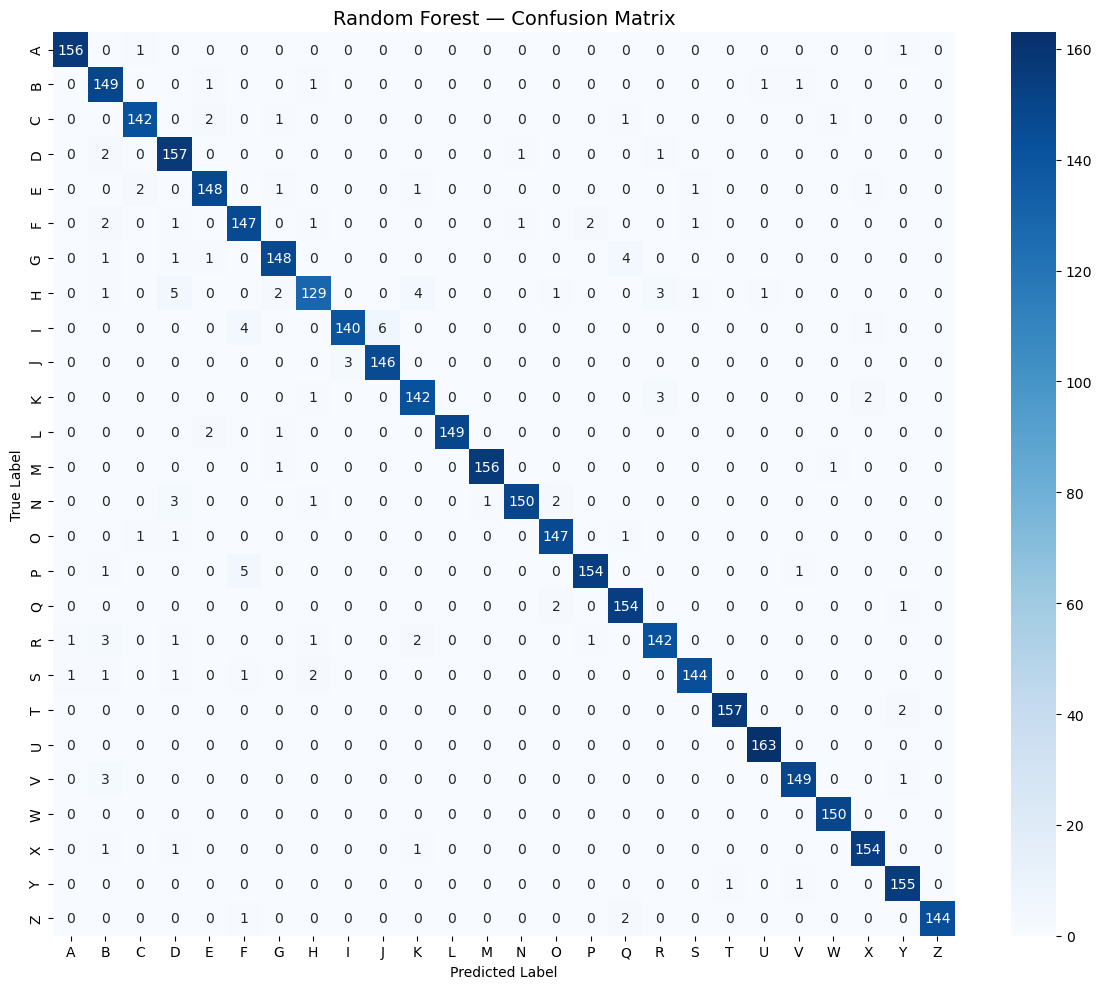

In [14]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plot.figure(figsize=(12, 10))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plot.title('Random Forest — Confusion Matrix', fontsize=14)
plot.xlabel('Predicted Label')
plot.ylabel('True Label')
plot.tight_layout()
plot.show()

### 4.3 K-Nearest Neighbours

Grid search over k (number of neighbours). Small k values tend to overfit; larger k values smooth boundaries.

In [15]:
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 15]}

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print("Best k:", knn_grid.best_params_)
knn_best = knn_grid.best_estimator_

Best k: {'n_neighbors': 3}


In [16]:
y_pred_knn = knn_best.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Test Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")

KNN Test Accuracy: 0.9495 (94.95%)


In [17]:
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

KNN Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.99      1.00       158
           B       0.91      0.95      0.93       153
           C       0.91      0.99      0.94       147
           D       0.89      0.96      0.92       161
           E       0.87      0.92      0.89       154
           F       0.92      0.91      0.91       155
           G       0.97      0.91      0.94       155
           H       0.89      0.90      0.90       147
           I       0.95      0.95      0.95       151
           J       0.95      0.95      0.95       149
           K       0.94      0.91      0.92       148
           L       0.98      0.98      0.98       152
           M       0.99      0.95      0.97       158
           N       0.95      0.92      0.94       157
           O       0.91      0.97      0.94       150
           P       0.95      0.91      0.93       161
           Q       0.98      0.96      0.97       157


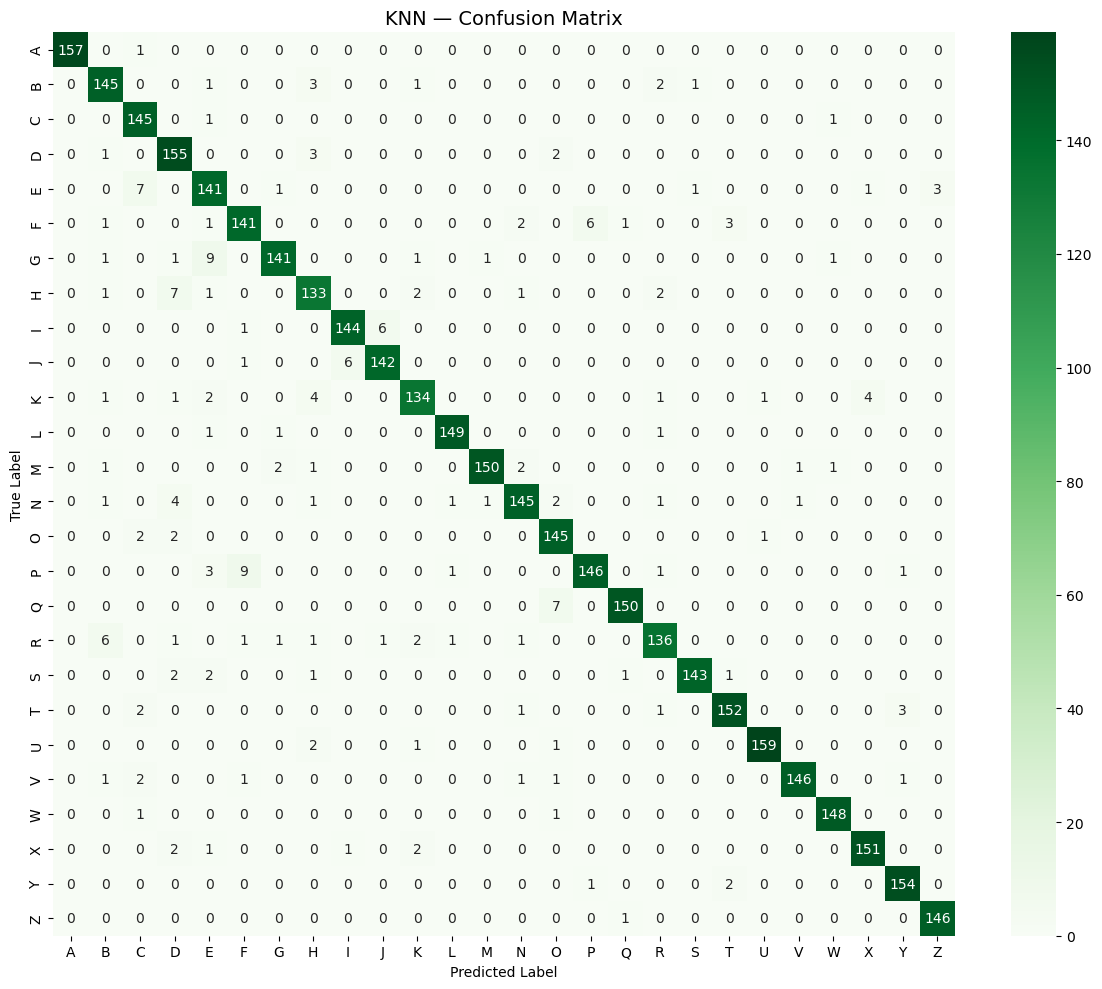

In [18]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
plot.figure(figsize=(12, 10))
sns.heatmap(
    cm_knn, annot=True, fmt='d', cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plot.title('KNN — Confusion Matrix', fontsize=14)
plot.xlabel('Predicted Label')
plot.ylabel('True Label')
plot.tight_layout()
plot.show()

## 5. Model Comparison

Summary of both models on the held-out test set.

In [19]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'KNN'],
    'Best Params': [str(rf_grid.best_params_), str(knn_grid.best_params_)],
    'Test Accuracy': [f"{rf_accuracy*100:.2f}%", f"{knn_accuracy*100:.2f}%"]
})
print(results.to_string(index=False))

print(f"\nRandom Forest outperforms KNN by {(rf_accuracy - knn_accuracy)*100:.2f} percentage points.")

        Model                                                                              Best Params Test Accuracy
Random Forest {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 150}        96.80%
          KNN                                                                       {'n_neighbors': 3}        94.95%

Random Forest outperforms KNN by 1.85 percentage points.
